# Wine Quality Prediction


##  Load and Inspect the Dataset

In [33]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Load the dataset
df = pd.read_csv("winequality-red.csv", sep=";")

In [35]:
# Display the first five rows
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Dataset Structure

In [36]:
df.shape

(1599, 12)

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [38]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# Exploratory Data Analysis (EDA)

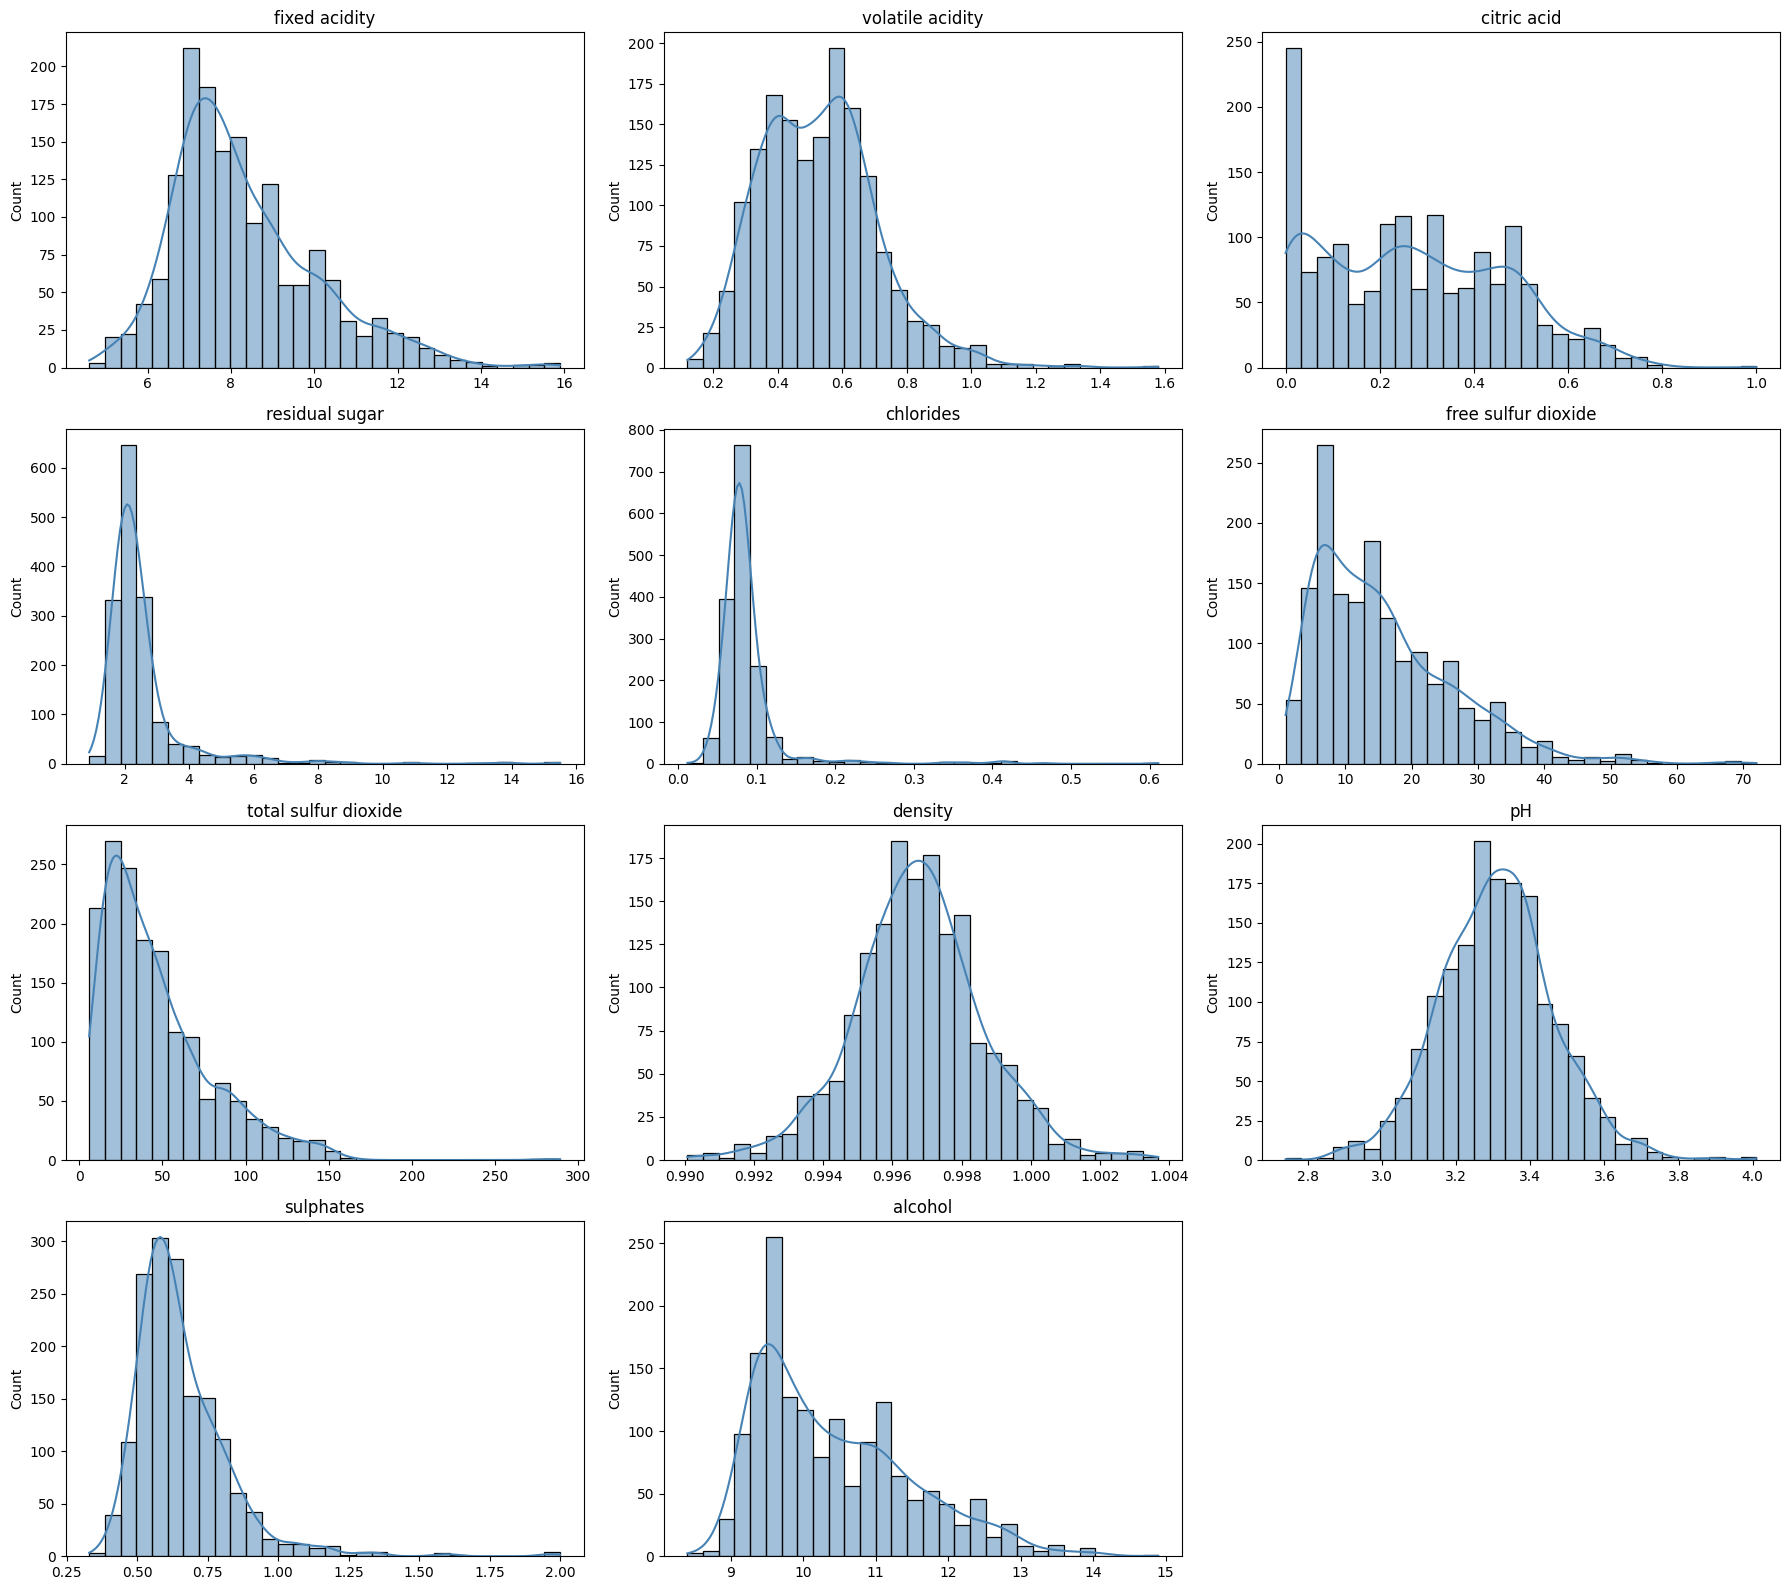

In [39]:
# Plot the distribution of all chemical features

features = df.columns[:-1]  # Exclude the target variable (quality)

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(df[feature], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Observations

- Most chemical features exhibit non-normal distributions, with several showing positive skewness.
- Features such as **residual sugar**, **chlorides**, and **free sulfur dioxide** contain a few extreme values, indicating potential outliers.
- **Alcohol** appears relatively well distributed compared to other variables.
- The variation in feature distributions suggests that scaling and robust machine learning algorithms may be beneficial during model training.

### Correlation Heatmap

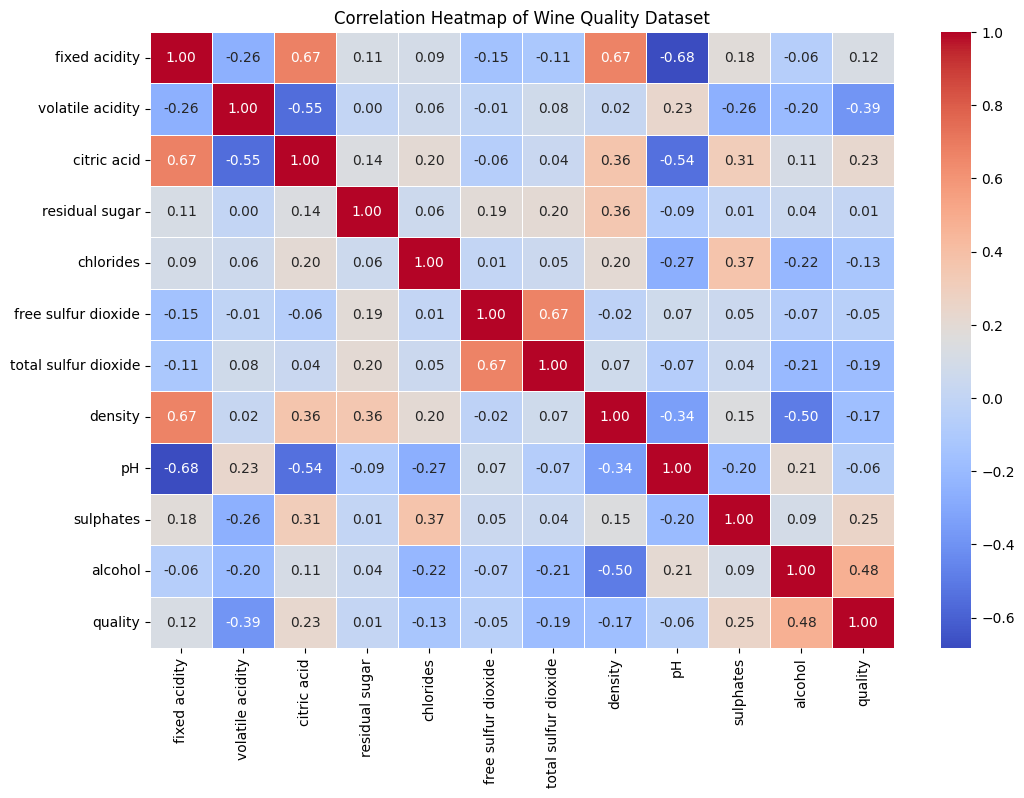

In [40]:
# Compute the correlation matrix
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Wine Quality Dataset")
plt.show()

### Observations

- **Alcohol** has the strongest positive correlation with wine quality, indicating that wines with higher alcohol content generally receive better quality ratings.
- **Volatile acidity** shows a noticeable negative correlation with quality, suggesting that higher volatile acidity is associated with lower-quality wines.
- **Citric acid** and **sulphates** exhibit weak positive correlations with quality.
- Most feature pairs have low to moderate correlations, indicating limited multicollinearity among the predictor variables.
- The correlation analysis suggests that multiple physicochemical properties collectively influence wine quality rather than a single dominant feature.

## Class Imbalance Analysis

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


C:\Users\saipr\AppData\Local\Temp\ipykernel_18080\3353222988.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="quality", palette="viridis")


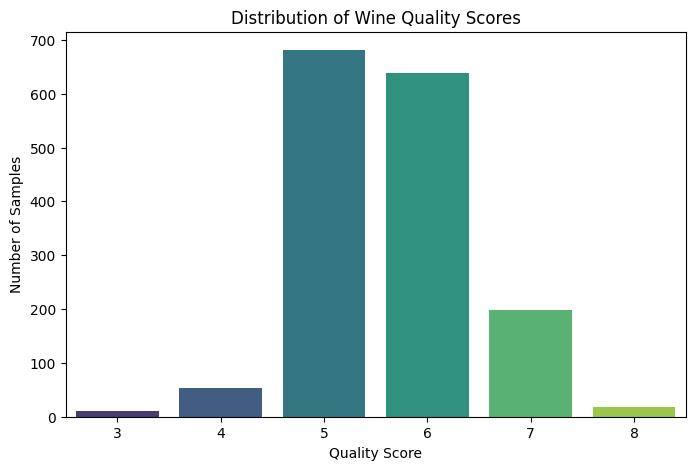

In [41]:
# Display the number of samples in each quality class
quality_counts = df["quality"].value_counts().sort_index()

print(quality_counts)

# Visualize the class distribution
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="quality", palette="viridis")

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Samples")

plt.show()

### Observations

- The distribution of wine quality scores is **highly imbalanced**, with quality scores **5** and **6** accounting for the majority of the samples.
- Quality scores **3**, **4**, and **8** are severely underrepresented, while quality score **7** has a moderate number of observations.
- This imbalance may bias machine learning models toward predicting the majority classes more frequently, resulting in poor performance for the minority classes.
- As a result, relying solely on **accuracy** may be misleading. Metrics such as **precision**, **recall**, and **F1-score** provide a more comprehensive evaluation of model performance.
- To maintain the original class distribution during model training and testing, a **stratified train-test split** will be used.

## Feature Engineering

In [42]:
# Convert wine quality into binary classes
# 0 = Bad (quality <= 5)
# 1 = Good (quality >= 6)

df["quality_label"] = df["quality"].apply(lambda x: 1 if x >= 6 else 0)

# Check the new class distribution
print(df["quality_label"].value_counts())

quality_label
1    855
0    744
Name: count, dtype: int64


C:\Users\saipr\AppData\Local\Temp\ipykernel_18080\2995069393.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="quality_label", palette="viridis")


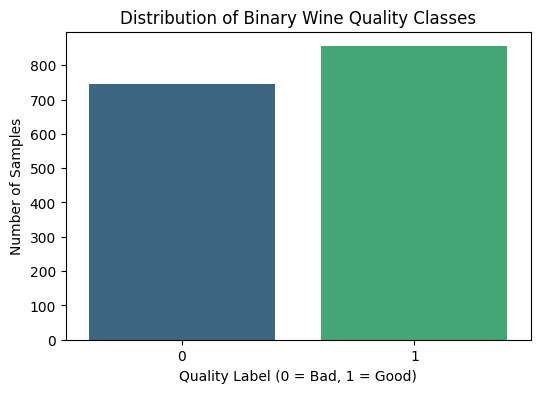

In [43]:
# Visualize the new target distribution
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="quality_label", palette="viridis")

plt.title("Distribution of Binary Wine Quality Classes")
plt.xlabel("Quality Label (0 = Bad, 1 = Good)")
plt.ylabel("Number of Samples")

plt.show()

### Observations

- The original quality scores were converted into two categories: **Bad (quality ≤ 5)** and **Good (quality ≥ 6)**.
- Binary classification was selected because the original dataset exhibits significant class imbalance, with quality scores **3**, **4**, and **8** containing very few samples.
- Grouping the classes produces a more balanced target distribution, enabling the machine learning models to learn more effectively and reducing bias toward majority classes.
- In addition, binary classification simplifies the prediction task and makes the model more practical for applications where the primary objective is to distinguish between good- and poor-quality wines.

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
# Separate features and target variable
X = df.drop(["quality", "quality_label"], axis=1)
y = df["quality_label"]

In [46]:
# Split the dataset while preserving class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [47]:
# Display the size of each set
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (1279, 11)
Testing set: (320, 11)


In [48]:
# Verify class distribution
print("\nTraining Set Class Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Set Class Distribution:")
print(y_test.value_counts(normalize=True))


Training Set Class Distribution:
quality_label
1    0.534793
0    0.465207
Name: proportion, dtype: float64

Testing Set Class Distribution:
quality_label
1    0.534375
0    0.465625
Name: proportion, dtype: float64


### Observations

- The dataset was divided into **80% training data** and **20% testing data**.
- **Stratified sampling** was used to ensure that the proportion of good- and bad-quality wines remained consistent across both the training and testing sets.
- Preserving the class distribution helps prevent sampling bias and enables a fair evaluation of the machine learning models on unseen data.
- A fixed `random_state` was specified to ensure that the results are reproducible.

## Model Training

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

In [50]:
# Standardize the feature values
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the classifiers
rf_model = RandomForestClassifier(random_state=42)

sgd_model = SGDClassifier(random_state=42)

svc_model = SVC(random_state=42)

# Train the models
rf_model.fit(X_train_scaled, y_train)

sgd_model.fit(X_train_scaled, y_train)

svc_model.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


### Observations

- Three classification models were trained: **Random Forest**, **Stochastic Gradient Descent (SGD)**, and **Support Vector Classifier (SVC)**.
- The feature values were standardized using **StandardScaler** before training to improve the performance of distance- and gradient-based algorithms.
- The trained models are now ready to make predictions on the test dataset and will be evaluated using accuracy, classification reports, and confusion matrices.

## Model Evaluation

In [51]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [52]:
# Store models in a dictionary
models = {
    "Random Forest": rf_model,
    "SGD": sgd_model,
    "Support Vector Classifier": svc_model
}


Random Forest
Accuracy: 0.8031

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.79       149
           1       0.83      0.80      0.81       171

    accuracy                           0.80       320
   macro avg       0.80      0.80      0.80       320
weighted avg       0.80      0.80      0.80       320



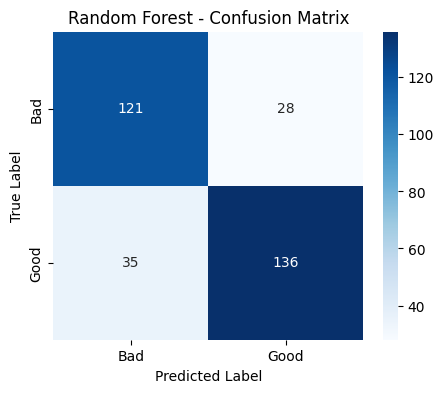

SGD
Accuracy: 0.6562

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.56      0.60       149
           1       0.66      0.74      0.70       171

    accuracy                           0.66       320
   macro avg       0.66      0.65      0.65       320
weighted avg       0.66      0.66      0.65       320



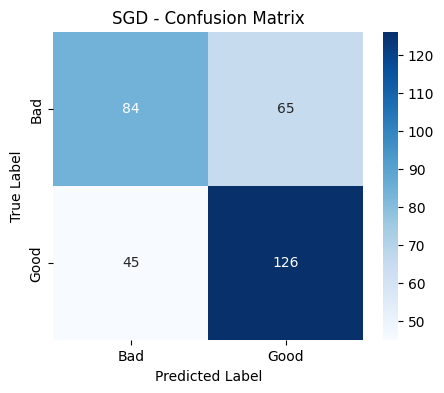

Support Vector Classifier
Accuracy: 0.7625

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.81      0.76       149
           1       0.81      0.72      0.76       171

    accuracy                           0.76       320
   macro avg       0.77      0.77      0.76       320
weighted avg       0.77      0.76      0.76       320



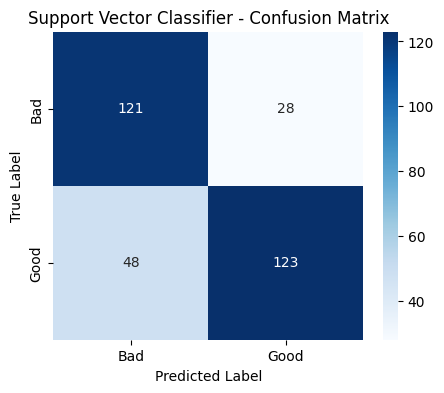

In [53]:
# Evaluate each model
for name, model in models.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}\n")

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Bad", "Good"],
        yticklabels=["Bad", "Good"]
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

### Observations

- Each classifier was evaluated using **accuracy**, **classification report**, and **confusion matrix**.
- The **accuracy score** provides an overall measure of correct predictions.
- The **classification report** summarizes precision, recall, F1-score, and support for each class, offering a more comprehensive evaluation than accuracy alone.
- The **confusion matrix** illustrates the number of correct and incorrect predictions for each class, helping identify the types of classification errors made by each model.
- The performance of the three classifiers will be compared in the following section to determine the most suitable model for deployment.

## Feature Importance of the Random Forest Model

C:\Users\saipr\AppData\Local\Temp\ipykernel_18080\2964837952.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


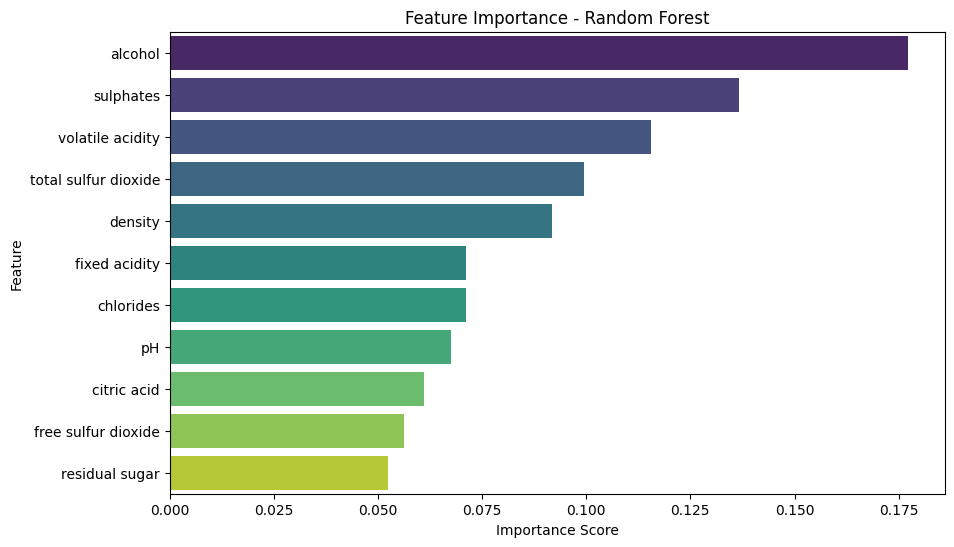

In [54]:
# Extract feature importances from the Random Forest model
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Plot feature importance
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

### Observations

- The Random Forest model ranks features based on their contribution to predicting wine quality.
- Features with higher importance scores have a greater influence on the model's predictions, while those with lower scores contribute less.
- In this dataset, **alcohol**, **volatile acidity**, **sulphates**, and **total sulfur dioxide** are among the most influential predictors of wine quality.
- Understanding feature importance improves model interpretability and provides insights into the physicochemical properties that most strongly affect wine quality.

## Model Performance Comparison

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dictionary to store model performance
results = []

for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

# Create comparison table
comparison_df = pd.DataFrame(results)

# Display the table
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.803125,0.829268,0.795322,0.811940
1,SGD,0.656250,0.659686,0.736842,0.696133
2,Support Vector Classifier,0.762500,0.814570,0.719298,0.763975


### Observations

- The table provides a side-by-side comparison of the three classification models using **Accuracy**, **Precision**, **Recall**, and **F1-score**.
- While accuracy measures overall prediction performance, the **F1-score** provides a better balance between precision and recall, making it a more reliable metric for evaluating models on this dataset.
- Comparing multiple evaluation metrics enables a more informed selection of the most suitable model for deployment.
- The model with the highest overall performance will be selected based on its ability to accurately classify both good- and bad-quality wines while maintaining a balanced precision and recall.

## Conclusion

Three machine learning classifiers—**Random Forest**, **Stochastic Gradient Descent (SGD)**, and **Support Vector Classifier (SVC)**—were trained and evaluated to predict wine quality based on physicochemical properties.

Among the evaluated models, the **Random Forest** classifier achieved the best overall performance, with an **accuracy of 80.31%**, **precision of 82.93%**, **recall of 79.53%**, and **F1-score of 81.19%**. It consistently outperformed the SGD and SVC models across all evaluation metrics, demonstrating a better balance between correctly identifying both good- and bad-quality wines.

The Random Forest model also provides feature importance scores, making its predictions more interpretable and helping identify the chemical properties that have the greatest influence on wine quality.

Based on its superior predictive performance, robustness, and interpretability, **Random Forest is the most suitable model for deployment** for binary wine quality classification.